# [Nguyen Nghia Doan Dang] — Individual Model Notebook
**Branch:** `student/<name>-model`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): Individual architecture
- **Model 2** (Phase 3): Refined architecture based on group discussion

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs uploaded to the shared Google Drive folder before running this notebook.

## 0. Install dependencies

In [ ]:
!pip install -q torch torchvision nltk Pillow matplotlib

## 1. Mount Google Drive & load processed data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Shared Drive paths
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = DRIVE_FOLDER / 'checkpoints'

STUDENT_NAME = 'Maris'
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Verify Drive artefacts exist
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING — run data_preparation.ipynb first'
    print(f'[{status}] {p.name}')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'[OK] images_224/ — {n_imgs:,} images')

Mounted at /content/drive
[OK] vocab.pkl
[OK] splits.json
[OK] captions_clean.json
[OK] images_224/ — 0 images


In [ ]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)

with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


## 2. Imports & device setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 3. Dataset & DataLoader

In [ ]:
from torch.utils.data import Dataset
class VizWizDataset(Dataset):
    def __init__(self, image_ids, captions, id_to_filename,
                 img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((Path(img_dir) / fname, indices))

        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, indices = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        caption = torch.tensor(indices, dtype=torch.long)
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)


BATCH_SIZE = 32

train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename,
                               DRIVE_IMAGES, word2idx, train_transform)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename,
                               DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename,
                               DRIVE_IMAGES, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f'Train: {len(train_dataset):,} samples | {len(train_loader):,} batches')
print(f'Val  : {len(val_dataset):,} samples | {len(val_loader):,} batches')
print(f'Test : {len(test_dataset):,} samples | {len(test_loader):,} batches')

Train: 29,997 samples | 938 batches
Val  : 3,758 samples | 118 batches
Test : 3,751 samples | 118 batches


---
# Model 1 — Phase 2 (Individual Architecture)


**Encoder:** GoogLeNet (Inception v1), pre-trained on ImageNet.

GoogLeNet uses Inception modules to efficiently collect multi-scale spatial features. Its compact architecture produces a robust 1024-dimensional global image representation with fewer parameters. The final FC layer is replaced by a projection to embed_dim=256. The last two Inception blocks (4d, 4e, 5a, 5b) are fine-tuned to fit image annotation.

**Decoder:** Single-layer LSTM (hidden_dim=512).

Image feature vectors initialize both h0 and c0, introducing visual context into each decoding step. Embedded words (embed_dim=256) are fed as input at each step using a mandatory training method during the training process.

In [ ]:
if isinstance(list(idx2word.keys())[0], str):
    idx2word = {int(k): v for k, v in idx2word.items()}

VOCAB_SIZE = len(word2idx)
print(f'Vocab size (fixed): {VOCAB_SIZE:,}')
assert VOCAB_SIZE > 0, 'Vocab is still empty — check vocab.pkl loaded correctly'

Vocab size (fixed): 3,965


In [ ]:
# Encoder - GooLeNet

import torch
import torch.nn as nn
import torchvision.models as models


class EncoderGoogLeNet(nn.Module):

    def __init__(self, embed_dim: int = 256, fine_tune: bool = True):
        super().__init__()

        base = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

        self.googlenet = base
        self.googlenet.fc = nn.Linear(1024, embed_dim)

        # Auxiliary classifiers are only used during GoogLeNet training;
        self.googlenet.aux_logits = False
        self.googlenet.aux1 = None
        self.googlenet.aux2 = None

        self.bn = nn.BatchNorm1d(embed_dim, momentum=0.01)

        # Fine-tuning strategy
        for param in self.googlenet.parameters():
            param.requires_grad = False

        if fine_tune:
            unfreeze_layers = [
                self.googlenet.inception4d,
                self.googlenet.inception4e,
                self.googlenet.inception5a,
                self.googlenet.inception5b,
                self.googlenet.fc,
            ]
            for layer in unfreeze_layers:
                for param in layer.parameters():
                    param.requires_grad = True

    def forward(self, images):
        """
        images : (B, 3, 224, 224)  ← standard ImageNet normalisation
        returns: (B, embed_dim)
        """
        features = self.googlenet(images)
        features = self.bn(features)
        return features

In [ ]:
# Encoder - LSTM
class DecoderLSTM(nn.Module):

    def __init__(self, embed_dim: int, hidden_dim: int, vocab_size: int,
                 num_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.init_h   = nn.Linear(embed_dim, hidden_dim)
        self.init_c   = nn.Linear(embed_dim, hidden_dim)
        self.lstm     = nn.LSTM(embed_dim, hidden_dim,
                                num_layers=num_layers,
                                batch_first=True,
                                dropout=dropout if num_layers > 1 else 0.0)
        self.dropout  = nn.Dropout(dropout)
        self.fc_out   = nn.Linear(hidden_dim, vocab_size)

    def init_hidden(self, img_features):
        h = torch.tanh(self.init_h(img_features)).unsqueeze(0)
        c = torch.tanh(self.init_c(img_features)).unsqueeze(0)
        return h, c

    def forward(self, img_features, captions):
        embeddings = self.dropout(self.embed(captions))
        h0, c0     = self.init_hidden(img_features)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        return logits

    @torch.no_grad()
    def generate_greedy(self, img_features, sos_idx, eos_idx,
                        max_len: int = 30):

        B      = img_features.size(0)
        h, c   = self.init_hidden(img_features)
        token  = torch.full((B, 1), sos_idx,
                            dtype=torch.long, device=img_features.device)
        seqs   = [[] for _ in range(B)]
        done   = [False] * B

        for _ in range(max_len):
            emb            = self.embed(token)
            out, (h, c)    = self.lstm(emb, (h, c))
            logits         = self.fc_out(out.squeeze(1))
            predicted      = logits.argmax(dim=1)

            for i in range(B):
                if not done[i]:
                    t = predicted[i].item()
                    if t == eos_idx:
                        done[i] = True
                    else:
                        seqs[i].append(t)

            if all(done):
                break

            token = predicted.unsqueeze(1)

        return seqs

In [ ]:
# Full Model Wrapper

class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size,
                 num_layers=1, dropout=0.5, fine_tune_cnn=True):
        super().__init__()
        self.encoder = EncoderGoogLeNet(embed_dim, fine_tune=fine_tune_cnn)
        self.decoder = DecoderLSTM(embed_dim, hidden_dim, vocab_size,
                                   num_layers, dropout)

    def forward(self, images, captions):
        features = self.encoder(images)
        logits   = self.decoder(features, captions)
        return logits

    @torch.no_grad()
    def generate(self, images, sos_idx, eos_idx, max_len=30):
        features = self.encoder(images)
        return self.decoder.generate_greedy(features, sos_idx, eos_idx, max_len)

# Instantiate
EMBED_DIM  = 256
HIDDEN_DIM = 512

model = ImageCaptioningModel(
    embed_dim      = EMBED_DIM,
    hidden_dim     = HIDDEN_DIM,
    vocab_size     = VOCAB_SIZE,
    num_layers     = 1,
    dropout        = 0.5,
    fine_tune_cnn  = True,
).to(DEVICE)

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 193MB/s]


Total params     : 10,752,029
Trainable params : 8,855,261


In [ ]:
# Loss & optimiser

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Two param groups: CNN (small lr) and decoder (larger lr)
cnn_params     = [p for p in model.encoder.parameters() if p.requires_grad]
decoder_params = list(model.decoder.parameters())

optimizer = torch.optim.Adam([
    {'params': cnn_params,     'lr': 1e-4},
    {'params': decoder_params, 'lr': 4e-4},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('Loss, optimiser, scheduler ready.')

Loss, optimiser, scheduler ready.


### Model 1 - Training

In [ ]:
# Training loop
import time

NUM_EPOCHS = 15
best_val_loss = float('inf')
train_losses, val_losses = [], []

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_tokens = 0.0, 0

    for images, captions, lengths in loader:
        images   = images.to(device)
        captions = captions.to(device)

        cap_input  = captions[:, :-1]
        cap_target = captions[:, 1:]

        optimizer.zero_grad()
        logits = model(images, cap_input)

        # Flatten for cross-entropy
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V),
                         cap_target.reshape(B * T))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Count non-pad tokens for a fair per-token loss
        n_tok      = (cap_target != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tok
        n_tokens   += n_tok

    return total_loss / n_tokens


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_tokens = 0.0, 0

    with torch.no_grad():
        for images, captions, lengths in loader:
            images   = images.to(device)
            captions = captions.to(device)

            cap_input  = captions[:, :-1]
            cap_target = captions[:, 1:]

            logits = model(images, cap_input)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V),
                             cap_target.reshape(B * T))

            n_tok      = (cap_target != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tok
            n_tokens   += n_tok

    return total_loss / n_tokens


# Run training
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train loss: {train_loss:.4f} | '
          f'Val loss: {val_loss:.4f} | '
          f'Time: {elapsed:.0f}s')

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        ckpt_path = MY_CHECKPTS / 'model1_best.pt'
        torch.save({
            'epoch':      epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':   val_loss,
            'embed_dim':  EMBED_DIM,
            'hidden_dim': HIDDEN_DIM,
            'vocab_size': VOCAB_SIZE,
        }, ckpt_path)
        print(f'  ✓ Saved best checkpoint → {ckpt_path}')

print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch 01/15 | Train loss: 4.2999 | Val loss: 3.7228 | Time: 2581s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt
Epoch 02/15 | Train loss: 3.6518 | Val loss: 3.4843 | Time: 893s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt
Epoch 03/15 | Train loss: 3.4226 | Val loss: 3.3664 | Time: 902s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt
Epoch 04/15 | Train loss: 3.2720 | Val loss: 3.2799 | Time: 900s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt
Epoch 05/15 | Train loss: 3.1654 | Val loss: 3.2413 | Time: 903s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt
Epoch 06/15 | Train loss: 3.0771 | Val loss: 3.1992 | Time: 905s
  ✓ Saved best checkpoint → /content/dr

In [ ]:
ckpt = torch.load(
    '/content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt',
    map_location=DEVICE
)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded epoch {ckpt["epoch"]}, val loss {ckpt["val_loss"]:.4f}')

Loaded epoch 12, val loss 3.1250


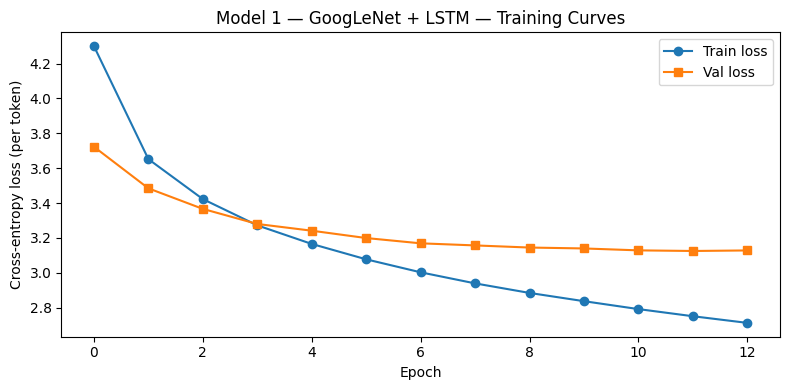

In [ ]:
# Plot Training curve
train_losses = [4.2999, 3.6518, 3.4226, 3.2720, 3.1654,
                3.0771, 3.0026, 2.9391, 2.8843, 2.8370,
                2.7916, 2.7507, 2.7125]

val_losses   = [3.7228, 3.4843, 3.3664, 3.2799, 3.2413,
                3.1992, 3.1689, 3.1569, 3.1447, 3.1395,
                3.1285, 3.1250, 3.1281]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss', marker='o')
ax.plot(val_losses,   label='Val loss',   marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (per token)')
ax.set_title('Model 1 — GoogLeNet + LSTM — Training Curves')
ax.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model1_training_curves.png', dpi=150)
plt.show()

### Model 1 — Evaluation (BLEU-1 to BLEU-4)

In [ ]:
import os
ckpt_base = '/content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints'
for folder in os.listdir(ckpt_base):
    print(folder)
    for f in os.listdir(f'{ckpt_base}/{folder}'):
        print(f'  └── {f}')

student_name
  └── model1_best.pt
  └── model1_sample_captions.png
Maris
  └── model1_training_curves.png


In [ ]:
ckpt = torch.load(
    '/content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pt',
    map_location=DEVICE
)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded epoch {ckpt["epoch"]}, val loss {ckpt["val_loss"]:.4f}')

Loaded epoch 12, val loss 3.1250


In [ ]:
MY_CHECKPTS = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name')

In [ ]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu(model, loader, idx2word, captions_clean,
                  id_to_filename, splits_subset, device, max_len=30):
    """
    Generates captions for all images in `loader` and computes
    BLEU-1 through BLEU-4 against all 5 reference captions.
    """
    model.eval()
    smoothie = SmoothingFunction().method1

    # Build filename
    fname_to_id = {v: k for k, v in id_to_filename.items()
                   if k in [str(i) for i in splits_subset]}

    hypotheses  = []
    references  = []

    # Track which image_ids we've already added references for
    seen_ids = set()

    with torch.no_grad():
        for images, captions, lengths in loader:
            images = images.to(device)
            seqs   = model.generate(images, SOS_IDX, EOS_IDX, max_len)

            for seq in seqs:
                hyp = [idx2word.get(t, '<UNK>') for t in seq]
                hypotheses.append(hyp)

    # Build references from captions_clean
    # Iterate loader in the same order as the dataset was built
    dataset = loader.dataset
    added   = 0
    for img_path, _ in dataset.samples:
        fname  = img_path.name
        img_id = fname_to_id.get(fname)
        if img_id is None:
            references.append([[]])
            continue
        refs = captions_clean.get(img_id,
               captions_clean.get(str(img_id), [[]]))
        references.append(refs)
        added += 1

    assert len(hypotheses) == len(references), \
        f'Mismatch: {len(hypotheses)} hyps vs {len(references)} refs'

    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0),
                        smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5, 0.5, 0, 0),
                        smoothing_function=smoothie)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(1/3, 1/3, 1/3, 0),
                        smoothing_function=smoothie)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoothie)

    return {
        'BLEU-1': round(bleu1, 4),
        'BLEU-2': round(bleu2, 4),
        'BLEU-3': round(bleu3, 4),
        'BLEU-4': round(bleu4, 4),
    }


# Load best checkpoint before evaluating
ckpt = torch.load(MY_CHECKPTS / 'model1_best.pt', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, val loss {ckpt["val_loss"]:.4f})')

bleu_scores = evaluate_bleu(
    model, test_loader, idx2word, captions_clean,
    id_to_filename, splits['test'], DEVICE
)

print('\n── Model 1 BLEU Scores (test set) ──')
for metric, score in bleu_scores.items():
    print(f'  {metric}: {score:.4f}')

Loaded best checkpoint (epoch 12, val loss 3.1250)

── Model 1 BLEU Scores (test set) ──
  BLEU-1: 0.5657
  BLEU-2: 0.4058
  BLEU-3: 0.2970
  BLEU-4: 0.2307


### Model 1 — Visual inspection

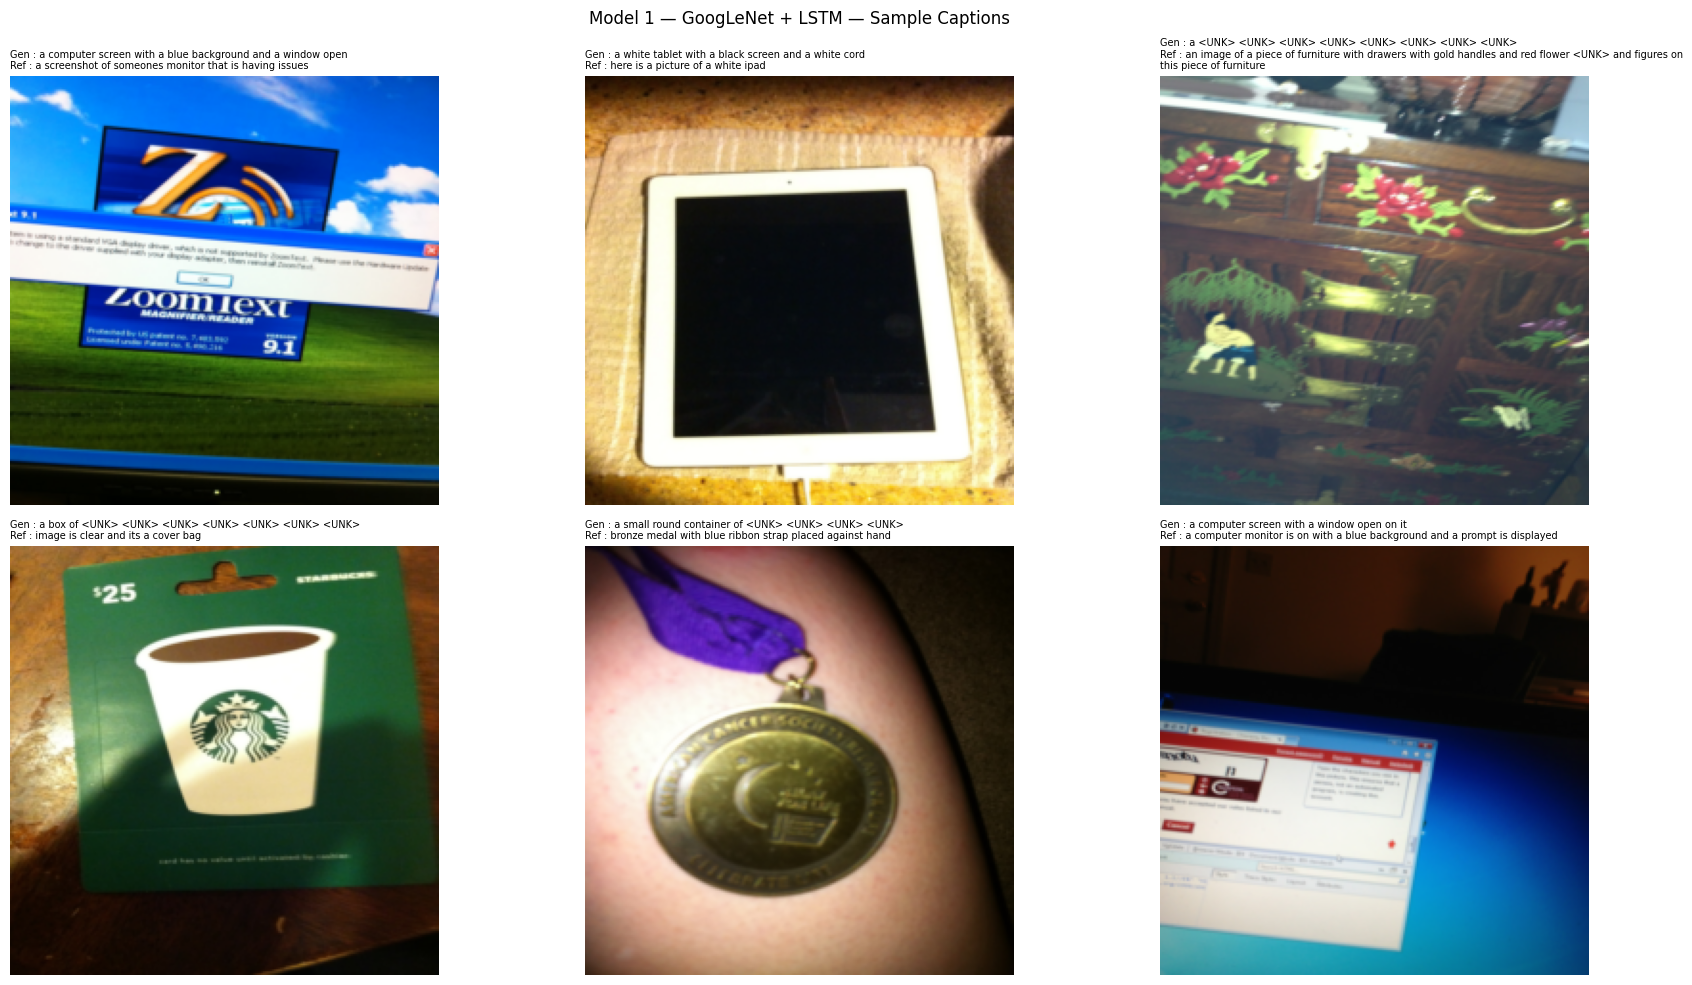

In [ ]:
def show_sample_captions(model, dataset, idx2word, device, n=6):
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for ax, idx in zip(axes.flat, indices):
        img_tensor, cap_tensor = dataset[idx]

        # Generate caption
        with torch.no_grad():
            seq = model.generate(
                img_tensor.unsqueeze(0).to(device),
                SOS_IDX, EOS_IDX, max_len=30
            )[0]
        generated = ' '.join(idx2word.get(t, '<UNK>') for t in seq)

        # Decode reference caption
        ref_tokens = cap_tensor.tolist()
        ref = ' '.join(
            idx2word.get(t, '<UNK>') for t in ref_tokens
            if t not in (PAD_IDX, SOS_IDX, EOS_IDX)
        )

        # Display image
        img_show = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img_show)
        ax.set_title(f'Gen : {generated}\nRef : {ref}',
                     fontsize=7, wrap=True, loc='left')
        ax.axis('off')

    plt.suptitle('Model 1 — GoogLeNet + LSTM — Sample Captions', fontsize=12)
    plt.tight_layout()
    plt.savefig(MY_CHECKPTS / 'model1_sample_captions.png', dpi=150)
    plt.show()


show_sample_captions(model, test_dataset, idx2word, DEVICE)

---
# Group Discussion Summary

After comparing Model 1 results between groups:

Key observations from the discussion:

1. Models compressing images into a single vector lose spatial information — words like "holding," "left," "on" require knowing the object's POSITION in the image

2. Attention mechanism identified as the most promising improvement

3. CNN refinement is more useful than complete freezing

**Decision for Model 2:** Add Bahdanau attention mechanism so the decoder can

focus on different spatial regions of the image at each word generation step.

---
# Model 2 — Phase 3 (Refined Architecture)

# Architectural Foundation — Model 2

Based on group discussion, the main weakness of Model 1 was compressing the entire image into a single vector, resulting in a loss of spatial detail.

**Changes over Model 1:**

1. The encoder now outputs a 7×7 (49-region) spatial feature map instead of a single composite vector — extracted from inception5b before performing global average synthesis.

2. Added Bahdanau attention (additive) mechanism — at each decoding step, the encoder calculates a weighted sum across all 49 spatial regions, focusing on the region most relevant to the current word.

3. LSTM input is now serialized: word embedding + context awareness,providing dynamic image context at each step.

4. Deep output layer combines latent state + context + word embedding for richer word predictions.

In [ ]:
# Encoder: GoogLeNet with spatial features

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt


class EncoderGoogLeNetSpatial(nn.Module):

    def __init__(self, encoder_dim: int = 512, fine_tune: bool = True):
        super().__init__()

        base = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

        self.conv1     = base.conv1
        self.maxpool1  = base.maxpool1
        self.conv2     = base.conv2
        self.conv3     = base.conv3
        self.maxpool2  = base.maxpool2
        self.inception3a = base.inception3a
        self.inception3b = base.inception3b
        self.maxpool3  = base.maxpool3
        self.inception4a = base.inception4a
        self.inception4b = base.inception4b
        self.inception4c = base.inception4c
        self.inception4d = base.inception4d
        self.inception4e = base.inception4e
        self.maxpool4  = base.maxpool4
        self.inception5a = base.inception5a
        self.inception5b = base.inception5b
        # Output: (B, 1024, 7, 7) for 224x224 input

        # Project each spatial region from 1024 → encoder_dim
        self.proj = nn.Sequential(
            nn.Conv2d(1024, encoder_dim, kernel_size=1),
            nn.BatchNorm2d(encoder_dim),
            nn.ReLU(),
        )

        # Freeze all, then selectively unfreeze
        for param in self.parameters():
            param.requires_grad = False

        if fine_tune:
            for layer in [self.inception4d, self.inception4e,
                          self.inception5a, self.inception5b,
                          self.proj]:
                for param in layer.parameters():
                    param.requires_grad = True

    def forward(self, images):

        x = self.conv1(images)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.maxpool2(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)
        x = self.inception4a(x)
        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        x = self.inception4e(x)
        x = self.maxpool4(x)
        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)
        x = x.view(B, H * W, C)
        return x

In [ ]:
# Bahdanau Attention

class BahdanauAttention(nn.Module):

    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att    = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):

        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att2 = att2.unsqueeze(1)

        energy = self.full_att(torch.tanh(att1 + att2))
        energy = energy.squeeze(2)

        alpha   = F.softmax(energy, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(1)

        return context, alpha

In [ ]:
# Attention LSTM Decoder

class DecoderWithAttention(nn.Module):

    def __init__(self, embed_dim, encoder_dim, decoder_dim,
                 attention_dim, vocab_size, dropout=0.5):
        super().__init__()

        self.attention  = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        self.embed      = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.init_h     = nn.Linear(encoder_dim, decoder_dim)
        self.init_c     = nn.Linear(encoder_dim, decoder_dim)
        self.lstm_cell  = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.dropout    = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(decoder_dim, vocab_size)

        # Deep output
        self.fc_context = nn.Linear(encoder_dim, vocab_size)
        self.fc_embed   = nn.Linear(embed_dim, vocab_size)

    def init_hidden(self, encoder_out):

        mean_enc = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, captions):
        B, T = captions.shape
        embeddings = self.dropout(self.embed(captions))

        h, c = self.init_hidden(encoder_out)
        logits = []

        for t in range(T):
            context, _ = self.attention(encoder_out, h)
            emb_t      = embeddings[:, t, :]

            lstm_input = torch.cat([emb_t, context], dim=1)
            h, c       = self.lstm_cell(lstm_input, (h, c))

            # Deep output combination
            out = (self.fc_out(self.dropout(h))
                   + self.fc_context(context)
                   + self.fc_embed(emb_t))
            logits.append(out)

        logits = torch.stack(logits, dim=1)
        return logits

    @torch.no_grad()
    def generate_greedy(self, encoder_out, sos_idx, eos_idx, max_len=30):

        B  = encoder_out.size(0)
        h, c = self.init_hidden(encoder_out)

        token    = torch.full((B,), sos_idx, dtype=torch.long,
                              device=encoder_out.device)
        seqs     = [[] for _ in range(B)]
        alphas   = [[] for _ in range(B)]
        done     = [False] * B

        for _ in range(max_len):
            emb            = self.embed(token)
            context, alpha = self.attention(encoder_out, h)

            lstm_input = torch.cat([emb, context], dim=1)
            h, c       = self.lstm_cell(lstm_input, (h, c))

            out = (self.fc_out(h)
                   + self.fc_context(context)
                   + self.fc_embed(emb))
            predicted = out.argmax(dim=1)

            for i in range(B):
                if not done[i]:
                    t = predicted[i].item()
                    if t == eos_idx:
                        done[i] = True
                    else:
                        seqs[i].append(t)
                        alphas[i].append(alpha[i].cpu())

            if all(done):
                break
            token = predicted

        return seqs, alphas

In [ ]:
# Full Model 2 wrapper

class ImageCaptioningModelV2(nn.Module):
    def __init__(self, encoder_dim, embed_dim, decoder_dim,
                 attention_dim, vocab_size, dropout=0.5, fine_tune_cnn=True):
        super().__init__()
        self.encoder = EncoderGoogLeNetSpatial(encoder_dim, fine_tune=fine_tune_cnn)
        self.decoder = DecoderWithAttention(
            embed_dim, encoder_dim, decoder_dim,
            attention_dim, vocab_size, dropout
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        logits   = self.decoder(features, captions)
        return logits

    @torch.no_grad()
    def generate(self, images, sos_idx, eos_idx, max_len=30):
        features = self.encoder(images)
        return self.decoder.generate_greedy(features, sos_idx, eos_idx, max_len)

# Hyperparameters
ENCODER_DIM   = 512
EMBED_DIM2    = 256
DECODER_DIM   = 512
ATTENTION_DIM = 256

model2 = ImageCaptioningModelV2(
    encoder_dim   = ENCODER_DIM,
    embed_dim     = EMBED_DIM2,
    decoder_dim   = DECODER_DIM,
    attention_dim = ATTENTION_DIM,
    vocab_size    = VOCAB_SIZE,
    dropout       = 0.5,
    fine_tune_cnn = True,
).to(DEVICE)

total_params     = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

Total params     : 15,641,624
Trainable params : 13,744,856


In [ ]:
# Loss & Optimiser

criterion2 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

cnn_params2     = [p for p in model2.encoder.parameters() if p.requires_grad]
decoder_params2 = list(model2.decoder.parameters())

optimizer2 = torch.optim.Adam([
    {'params': cnn_params2,     'lr': 1e-4},
    {'params': decoder_params2, 'lr': 4e-4},
])

scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', factor=0.5, patience=2
)

print('Model 2 loss, optimiser, scheduler ready.')

Model 2 loss, optimiser, scheduler ready.


### Model 2 — Training

In [ ]:
# Training Loop
import time

def train_one_epoch_v2(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_tokens = 0.0, 0

    for images, captions, lengths in loader:
        images   = images.to(device)
        captions = captions.to(device)

        cap_input  = captions[:, :-1]
        cap_target = captions[:, 1:]

        optimizer.zero_grad()
        logits = model(images, cap_input)

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V),
                         cap_target.reshape(B * T))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        n_tok      = (cap_target != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tok
        n_tokens   += n_tok

    return total_loss / n_tokens


def evaluate_v2(model, loader, criterion, device):
    model.eval()
    total_loss, n_tokens = 0.0, 0

    with torch.no_grad():
        for images, captions, lengths in loader:
            images   = images.to(device)
            captions = captions.to(device)

            cap_input  = captions[:, :-1]
            cap_target = captions[:, 1:]

            logits = model(images, cap_input)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V),
                             cap_target.reshape(B * T))

            n_tok      = (cap_target != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tok
            n_tokens   += n_tok

    return total_loss / n_tokens


NUM_EPOCHS2    = 15
best_val_loss2 = float('inf')
train_losses2, val_losses2 = [], []

for epoch in range(1, NUM_EPOCHS2 + 1):
    t0 = time.time()

    train_loss = train_one_epoch_v2(model2, train_loader, optimizer2, criterion2, DEVICE)
    val_loss   = evaluate_v2(model2, val_loader, criterion2, DEVICE)
    scheduler2.step(val_loss)

    train_losses2.append(train_loss)
    val_losses2.append(val_loss)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS2} | '
          f'Train loss: {train_loss:.4f} | '
          f'Val loss: {val_loss:.4f} | '
          f'Time: {elapsed:.0f}s')

    if val_loss < best_val_loss2:
        best_val_loss2 = val_loss
        ckpt_path = MY_CHECKPTS / 'model2_best.pt'
        torch.save({
            'epoch':        epoch,
            'model_state_dict': model2.state_dict(),
            'optimizer_state_dict': optimizer2.state_dict(),
            'val_loss':     val_loss,
            'encoder_dim':  ENCODER_DIM,
            'embed_dim':    EMBED_DIM2,
            'decoder_dim':  DECODER_DIM,
            'attention_dim': ATTENTION_DIM,
            'vocab_size':   VOCAB_SIZE,
        }, ckpt_path)
        print(f'  ✓ Saved best checkpoint → {ckpt_path}')

print(f'\nBest val loss: {best_val_loss2:.4f}')

Epoch 01/15 | Train loss: 4.0082 | Val loss: 3.4733 | Time: 1917s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/Maris/model2_best.pt
Epoch 02/15 | Train loss: 3.2060 | Val loss: 3.3129 | Time: 815s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/Maris/model2_best.pt
Epoch 03/15 | Train loss: 2.8611 | Val loss: 3.2844 | Time: 834s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/Maris/model2_best.pt
Epoch 04/15 | Train loss: 2.6350 | Val loss: 3.2642 | Time: 836s
  ✓ Saved best checkpoint → /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/Maris/model2_best.pt
Epoch 05/15 | Train loss: 2.4692 | Val loss: 3.2804 | Time: 845s
Epoch 06/15 | Train loss: 2.3381 | Val loss: 3.2866 | Time: 835s
Epoch 07/15 | Train loss: 2.2309 | Val loss: 3.3170 | Time: 841s
Epoch 08/15 | Train loss: 2.0526 | Val loss: 3.3568 | Time: 826s
Epoch 09/15 | Train loss: 1.9887 | Val loss: 3.3850

KeyboardInterrupt: 

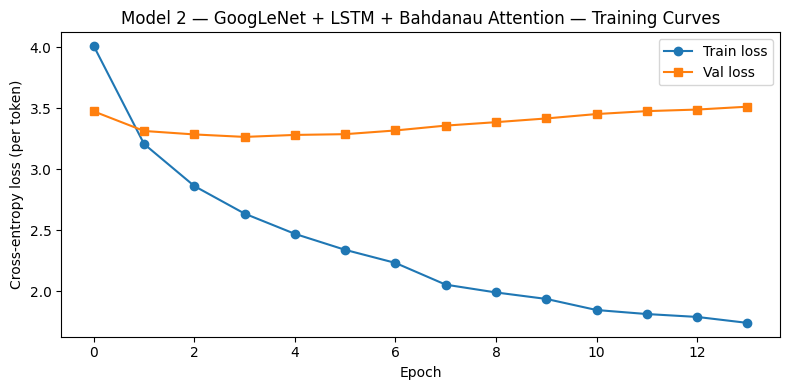

In [ ]:
# Training Curves

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses2, label='Train loss', marker='o')
ax.plot(val_losses2,   label='Val loss',   marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (per token)')
ax.set_title('Model 2 — GoogLeNet + LSTM + Bahdanau Attention — Training Curves')
ax.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model2_training_curves.png', dpi=150)
plt.show()


### Model 2 — Evaluation & comparison vs. Model 1

In [ ]:
# BLEU Evaluation

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu_v2(model, loader, idx2word, captions_clean,
                     id_to_filename, splits_subset, device, max_len=30):
    model.eval()
    smoothie = SmoothingFunction().method1

    fname_to_id = {v: k for k, v in id_to_filename.items()
                   if k in [str(i) for i in splits_subset]}

    hypotheses = []
    references = []

    with torch.no_grad():
        for images, captions, lengths in loader:
            images = images.to(device)
            seqs, _ = model.generate(images, SOS_IDX, EOS_IDX, max_len)
            for seq in seqs:
                hyp = [idx2word.get(t, '<UNK>') for t in seq]
                hypotheses.append(hyp)

    dataset = loader.dataset
    for img_path, _ in dataset.samples:
        fname  = img_path.name
        img_id = fname_to_id.get(fname)
        if img_id is None:
            references.append([[]])
            continue
        refs = captions_clean.get(img_id,
               captions_clean.get(str(img_id), [[]]))
        references.append(refs)

    assert len(hypotheses) == len(references)

    bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

    return {
        'BLEU-1': round(bleu1, 4),
        'BLEU-2': round(bleu2, 4),
        'BLEU-3': round(bleu3, 4),
        'BLEU-4': round(bleu4, 4),
    }


# Load best checkpoint
ckpt2 = torch.load(MY_CHECKPTS / 'model2_best.pt', map_location=DEVICE)
model2.load_state_dict(ckpt2['model_state_dict'])
print(f'Loaded best checkpoint (epoch {ckpt2["epoch"]}, val loss {ckpt2["val_loss"]:.4f})')

bleu_scores2 = evaluate_bleu_v2(
    model2, test_loader, idx2word, captions_clean,
    id_to_filename, splits['test'], DEVICE
)

print('\n── Model 2 BLEU Scores (test set) ──')
for metric, score in bleu_scores2.items():
    print(f'  {metric}: {score:.4f}')

Loaded best checkpoint (epoch 4, val loss 3.2642)

── Model 2 BLEU Scores (test set) ──
  BLEU-1: 0.5787
  BLEU-2: 0.4231
  BLEU-3: 0.3158
  BLEU-4: 0.2488


In [ ]:
# Model Comparison

model1_scores = {'BLEU-1': 0.5657, 'BLEU-2': 0.4058,
                 'BLEU-3': 0.2970, 'BLEU-4': 0.2307}

print('─' * 45)
print(f'{"Metric":<12} {"Model 1":>10} {"Model 2":>10} {"Δ":>8}')
print('─' * 45)
for metric in ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']:
    m1 = model1_scores[metric]
    m2 = bleu_scores2[metric]
    delta = m2 - m1
    arrow = '▲' if delta > 0 else '▼'
    print(f'{metric:<12} {m1:>10.4f} {m2:>10.4f} {arrow}{abs(delta):>6.4f}')
print('─' * 45)


─────────────────────────────────────────────
Metric          Model 1    Model 2        Δ
─────────────────────────────────────────────
BLEU-1           0.5657     0.5787 ▲0.0130
BLEU-2           0.4058     0.4231 ▲0.0173
BLEU-3           0.2970     0.3158 ▲0.0188
BLEU-4           0.2307     0.2488 ▲0.0181
─────────────────────────────────────────────


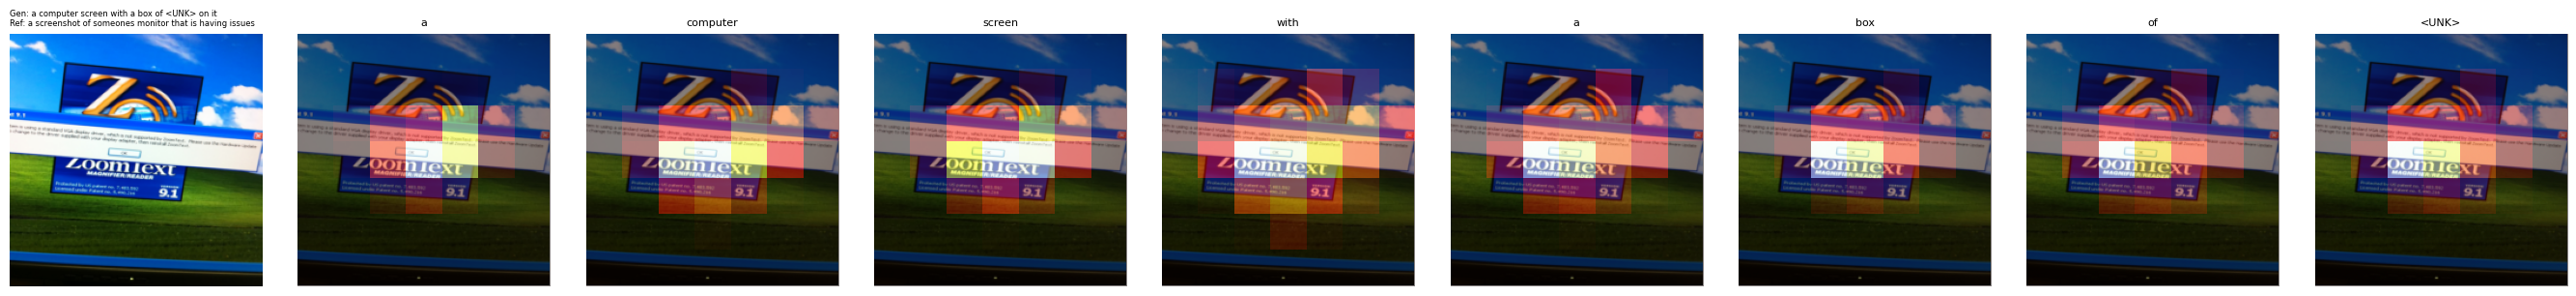

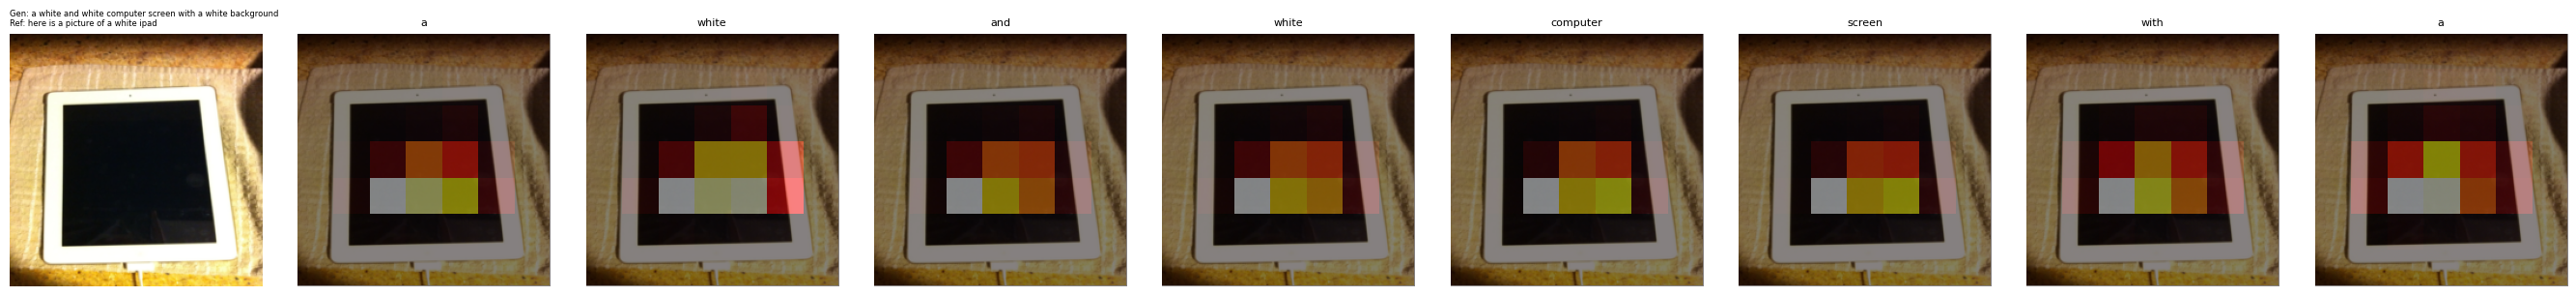

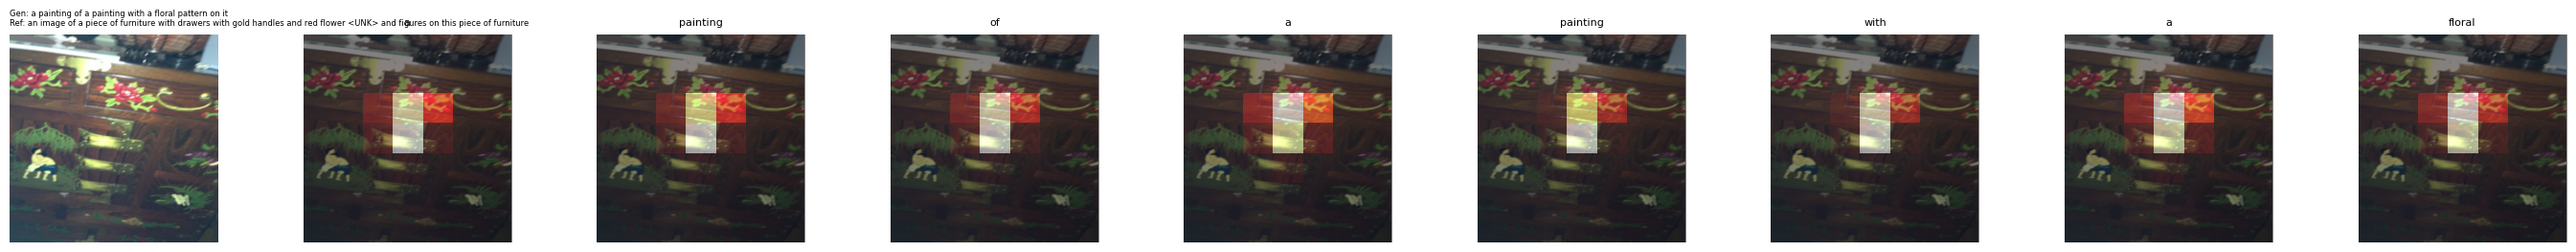

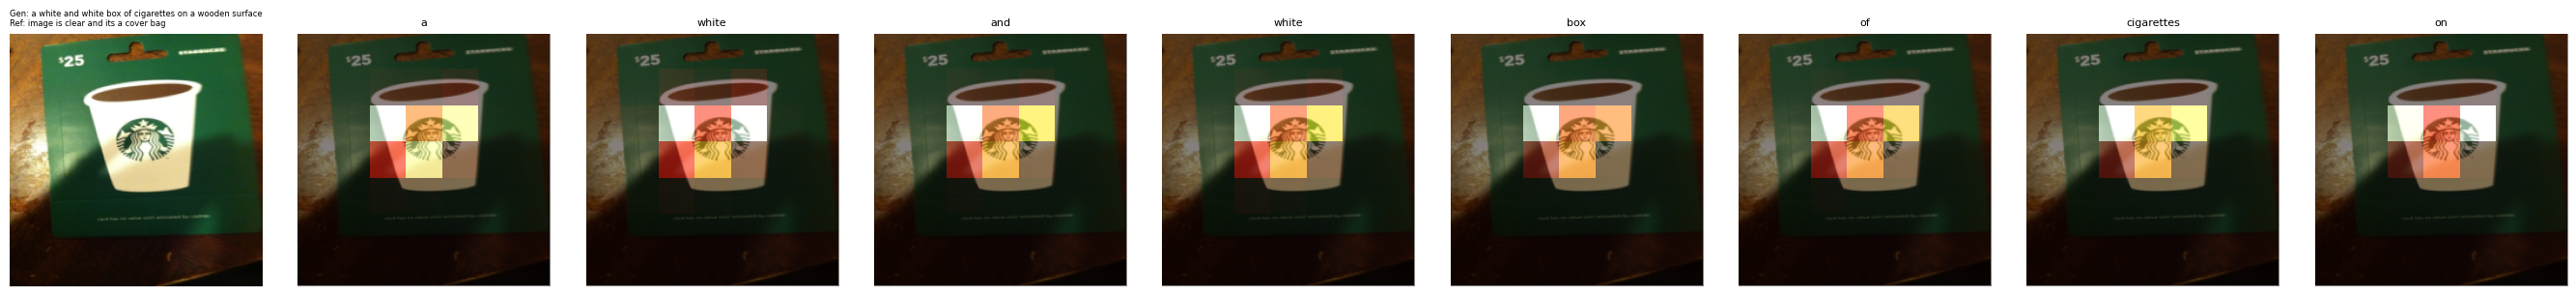

In [ ]:
# Visual Inspection + Attention Map
def show_attention(model, dataset, idx2word, device, n=4):
    """Show generated captions with attention heatmaps."""
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    for idx in indices:
        img_tensor, cap_tensor = dataset[idx]

        with torch.no_grad():
            seqs, alphas = model.generate(
                img_tensor.unsqueeze(0).to(device),
                SOS_IDX, EOS_IDX, max_len=30
            )

        seq    = seqs[0]
        alphas = alphas[0]  # list of (49,) tensors
        words  = [idx2word.get(t, '<UNK>') for t in seq]

        # Decode reference
        ref_tokens = cap_tensor.tolist()
        ref = ' '.join(idx2word.get(t, '<UNK>') for t in ref_tokens
                       if t not in (PAD_IDX, SOS_IDX, EOS_IDX))

        img_show = (img_tensor * std + mean).clamp(0,1).permute(1,2,0).numpy()

        # Show image + caption
        n_words = min(len(words), 8)  # show attention for first 8 words
        fig, axes = plt.subplots(1, n_words + 1,
                                 figsize=(3 * (n_words + 1), 3))

        axes[0].imshow(img_show)
        axes[0].set_title(f'Gen: {" ".join(words)}\nRef: {ref}',
                          fontsize=6, loc='left')
        axes[0].axis('off')

        for i in range(n_words):
            if i < len(alphas):
                attn = alphas[i].reshape(7, 7).numpy()
                attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

                axes[i+1].imshow(img_show)
                axes[i+1].imshow(attn, alpha=0.5, cmap='hot',
                                 extent=[0, 224, 224, 0])
                axes[i+1].set_title(words[i], fontsize=8)
                axes[i+1].axis('off')

        plt.tight_layout()
        plt.savefig(MY_CHECKPTS / f'model2_attention_{idx}.png', dpi=120)
        plt.show()


show_attention(model2, test_dataset, idx2word, DEVICE)